# Week 3 Excercises

## Q1

1. H is the Hessian 
2. g are the linear constants 
3. A are the LHS of the equaliti constraints
4. b er the RHS of the equality constraints

In [2]:
import numpy as np 
import sympy as sp

P = sp.Matrix([
    [3, 1, 0.5], 
    [1, 2.5, 1], 
    [0.5, 1, 2]
])

H = P*2 

x = sp.Matrix(sp.symbols('x1 x2 x3')) 

g = sp.Matrix([-8, -3, -3])

f = (1/2)*x.T*H*x + g.T*x
f[0].expand()

3.0*x1**2 + 2.0*x1*x2 + 1.0*x1*x3 - 8*x1 + 2.5*x2**2 + 2.0*x2*x3 - 3*x2 + 2.0*x3**2 - 3*x3

## Q2

Writing up the KKT optimality conditions: 

$$
\nabla \mathcal{L}(x, \lambda) = Hx + g - \lambda_1 \nabla c_1(x) + \lambda_2 \nabla c_2(x) = 0 
$$

where

$$
\nabla c_1(x) = (1, 0, 1)^T
 $$

$$
\nabla c_2(x) = (0, 1, 1)^T
$$

s.t.

$$
c_i(x) = 0
$$

Matrix is: 

$$
\begin{bmatrix}
\nabla f & 
\end{bmatrix}
$$

In [42]:
from scipy.linalg import ldl 
import numpy as np

def EqualityQPSolver(H : np.ndarray,g : np.ndarray,A : np.ndarray,b : np.ndarray): 
    d = -b 
    rhs = np.concatenate((g.flatten(), d.flatten())) 
    M = np.block([[H, -A], 
                  [-A.T, np.zeros((A.shape[1], A.shape[1]))]])
    L, D, perm = ldl(M) 
    y = np.linalg.solve(L, rhs[perm]) 
    z = np.linalg.solve(D, y) 
    x = np.linalg.solve(L.T, z) 

    return M, x


b = np.array([3,0]) 

A = np.array([
    [1, 0, 1], 
    [0, 1, 1]
]).T

H = np.array(H).astype(np.float64) 
print(H)
print(g)
g = np.array(g).astype(np.float64) 
M, solution = EqualityQPSolver(H, g, A, b) 
print("Optimal solution: X", solution[:3])
print("Solution for Lagrange multipliers: Lambda", solution[3:])



[[6. 2. 1.]
 [2. 5. 2.]
 [1. 2. 4.]]
[[-8.]
 [-3.]
 [-3.]]
Optimal solution: X [ 0.76923077 -2.23076923  2.23076923]
Solution for Lagrange multipliers: Lambda [10.38461538 -2.15384615]


In [ ]:
d = -b 

rhs = np.concatenate((g.flatten(), d.flatten())) 

np.linalg.solve(M, rhs)

array([ 0.76923077, -2.23076923,  2.23076923, 10.38461538, -2.15384615])

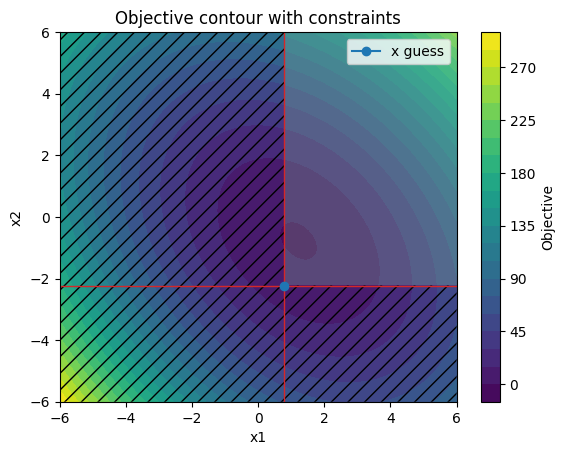

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Objective contour with constraints'}, xlabel='x1', ylabel='x2'>)

In [46]:
from src.optim.plot import Plotter


def f1(x):
    x = np.concatenate((x, [2.23076923]))  

    result = 1/2 * x.T @ H @ x + g.T @ x 
    return result.flatten()[0]  # return as scalar


x3 = solution[2]


constraints = [

    lambda x: x[0] + x3 - 3,

    lambda x: x[1] + x3,
    
]  # each <= 0 is feasible



plotter = Plotter(objective=f1, constraints=constraints, x=np.array(solution[:2]))

plotter.plot_contour(
    xlim=(-6, 6),
    ylim=(-6, 6),
    grid_size=400,  # increase if you want smoother contours
)

In [38]:
x1 = solution[:2]
x2 = np.array([ 1.8, 0.3]) 


print("f1 at x1:", f1(x1))
print("f1 at x2:", f1(x2))

f1 at x1: 20.014792899408285
f1 at x2: -1.674999999999999


# Q6